In [ ]:
!pip install -q datasets matplotlib pillow

In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [ ]:
dataset = load_dataset("nelorth/oxford-flowers")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-12de94e121bdbe(…):   0%|          | 0.00/303M [00:00<?, ?B/s]

data/test-00000-of-00001-96eeec628415add(…):   0%|          | 0.00/43.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7169 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1020 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 7169
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1020
    })
})


In [ ]:
sample = dataset["train"][0]

print("Keys in dataset:", sample.keys())
print("Label:", sample["label"])
print("Image type:", type(sample["image"]))

Keys in dataset: dict_keys(['image', 'label'])
Label: 0
Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>


In [ ]:
labels = dataset["train"]["label"]
num_classes = len(set(labels))

print("Number of classes:", num_classes)

Number of classes: 102


In [ ]:
widths = []
heights = []

for i in range(100):  # sample first 100 images
    img = dataset["train"][i]["image"]
    w, h = img.size
    widths.append(w)
    heights.append(h)

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

Average width: 617.54
Average height: 525.46


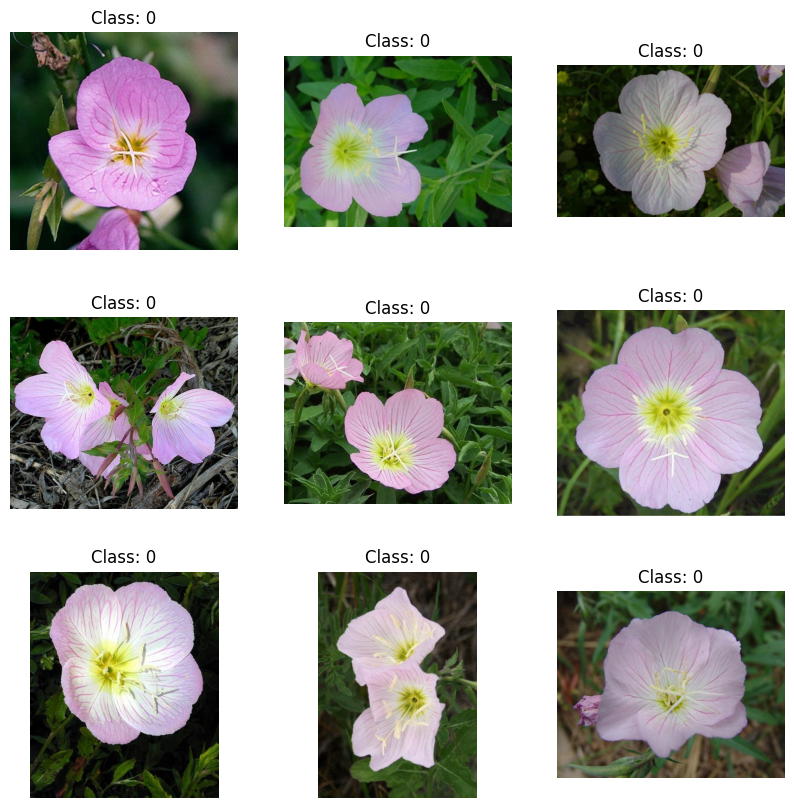

In [ ]:
plt.figure(figsize=(10,10))

for i in range(9):
    img = dataset["train"][i]["image"]
    label = dataset["train"][i]["label"]

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"Class: {label}")
    plt.axis("off")

plt.show()

In [ ]:
import collections

label_counts = collections.Counter(labels)

print("Sample class distribution:")
for k, v in list(label_counts.items())[:10]:
    print(f"Class {k}: {v} images")

Sample class distribution:
Class 0: 31 images
Class 1: 36 images
Class 2: 39 images
Class 3: 49 images
Class 4: 37 images
Class 5: 76 images
Class 6: 77 images
Class 7: 39 images
Class 8: 37 images
Class 9: 39 images


In [ ]:
def generate_caption(label):
    return f"A photo of a flower of class {label}"

dataset = dataset.map(lambda x: {"caption": generate_caption(x["label"])})

Map:   0%|          | 0/7169 [00:00<?, ? examples/s]

Map:   0%|          | 0/1020 [00:00<?, ? examples/s]

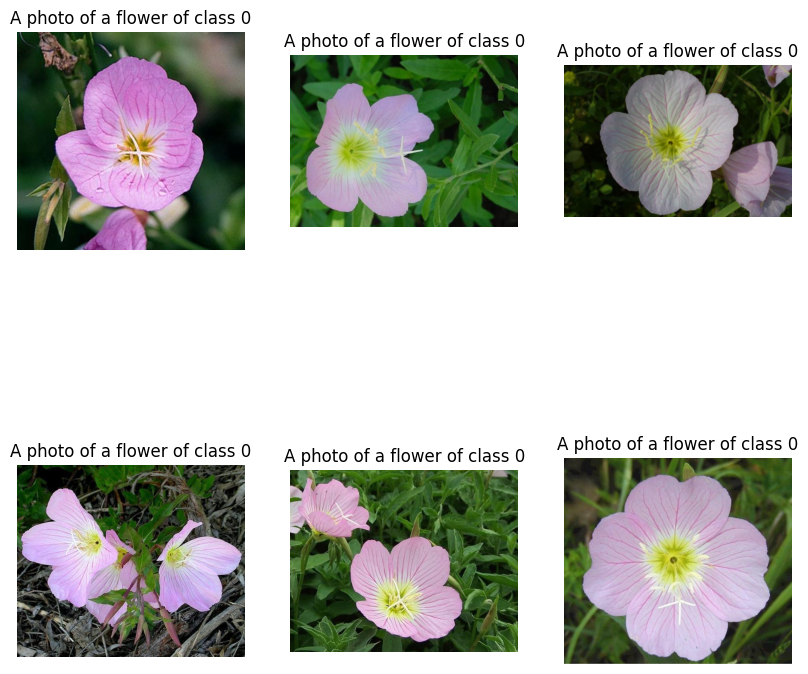

In [ ]:
plt.figure(figsize=(10,10))

for i in range(6):
    img = dataset["train"][i]["image"]
    caption = dataset["train"][i]["caption"]

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(caption)
    plt.axis("off")

plt.show()

In [ ]:
caption_lengths = [len(x.split()) for x in dataset["train"]["caption"]]

print("Average caption length:", np.mean(caption_lengths))
print("Max caption length:", max(caption_lengths))
print("Min caption length:", min(caption_lengths))

Average caption length: 8.0
Max caption length: 8
Min caption length: 8
